In [64]:
# autoreload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Error Analysis and Model Interpretability

## Setup and Dependencies

In [65]:
import pandas as pd
import numpy as np
from utils.paths import models_dir
from evaluation.metrics import ClassificationMetrics
import joblib
import shap


## Model and Test Data Loading

In [66]:
model_dict = joblib.load(models_dir("wisconsin_best_model.pkl"))
model = model_dict["model"]
selected_features = model_dict["selected_features"]
X_test = model_dict["X_test"]
y_test = model_dict["y_test"]

## Test Set Evaluation

This section evaluates the performance of the trained model on the held-out test set.

The goal is to assess generalization performance using relevant metrics, including sensitivity, specificity, and macro F1-score.

The confusion matrix and classification report provide insight into how well the model distinguishes between malignant and benign cases.

In [67]:
y_pred = model.predict(X_test[selected_features])
y_pred_proba = model.predict_proba(X_test[selected_features])[:,1]

Confusion matrix


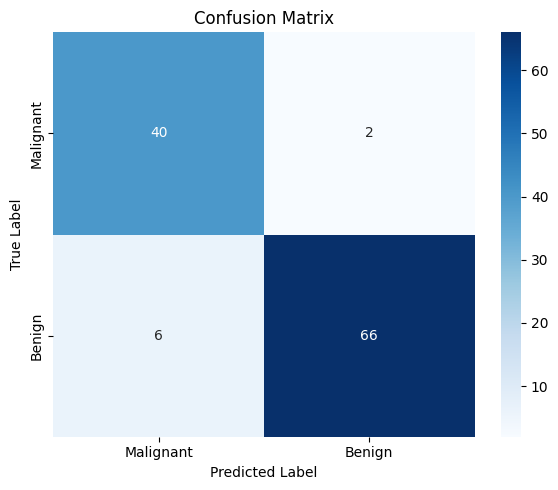

In [68]:
metrics = ClassificationMetrics(y_true=y_test,
                                y_pred=y_pred,
                                y_proba=y_pred_proba
                                )
print("Confusion matrix")
metrics.plot_confusion_matrix(return_fig=False)

In [69]:
print("Classification report")
metrics.plot_classification_report(return_fig=False,
                                   print_df=True)

Classification report
              precision  recall  f1-score  support
0                  0.87    0.95      0.91    42.00
1                  0.97    0.92      0.94    72.00
accuracy           0.93    0.93      0.93     0.93
macro avg          0.92    0.93      0.93   114.00
weighted avg       0.93    0.93      0.93   114.00


In [70]:
print("Additional metrics")
df_metrics = pd.DataFrame([metrics.get_metrics()])
print(df_metrics)

Additional metrics
   roc_auc  f1_macro  sensitivity  specificity
0     0.99      0.93         0.92         0.95


The **confusion matrix** shows that the model achieves a very high level of accuracy, correctly classifying 106 out of 114 patients, which corresponds to an overall accuracy of 93%. Only 8 cases were misclassified, with the majority of errors occurring in benign patients who were predicted as malignant. Importantly, the model almost never misses malignant cases, with only 2 mistakes. This is a remarkable outcome in a medical context. The matrix therefore reflects a model that is both cautious and highly reliable.

The **classification report** reinforces this strong performance. For malignant cases (class 0), the recall reaches 95%, meaning the model successfully detects nearly all malignant tumors. For benign cases (class 1), the precision is exceptionally high at 97%, indicating that when the model predicts benignity, it is almost always correct. Both classes achieve F1-scores above 0.90, and the overall accuracy remains at 93%. These results demonstrate that the model is not only accurate but also balanced, maintaining excellent performance across both malignant and benign classifications.

Additional metrics further highlight the robustness of the model. The ROC AUC is 0.99, which is nearly perfect and shows that the model has an outstanding ability to discriminate between the two classes. Sensitivity is 0.92, while specificity is 0.95, confirming that the model is consistent and dependable in both detecting malignancy and confirming benignity. Taken together, these metrics emphasize that the model’s performance is exceptional.



## Model Interpretability with SHAP

To better understand model behavior, SHAP is used to estimate the contribution of each feature to the model predictions.

The analysis includes:
- Global feature importance
- Feature impact distribution
- Comparison between correctly and incorrectly classified samples

In [81]:
X_test_scaled = X_test_scaled = model.named_steps['scaler'].transform(X_test[selected_features])
explainer = shap.TreeExplainer(model.named_steps['estimator'], X_test_scaled)
shap_values = explainer(X_test_scaled)
expected_value = explainer.expected_value

In [82]:
misclassified_idx = np.where(y_test != y_pred)[0]
shap_values_mis = shap_values[misclassified_idx]

correct_idx = np.where(y_test == y_pred)[0]
shap_values_correct = shap_values[correct_idx]

print("Correct samples:", len(correct_idx))
print("Misclassified samples:", len(misclassified_idx))

Correct samples: 106
Misclassified samples: 8


### Feature Importance (Shap Bar Plot)
This plot shows the most important features driving model predictions across the entire test set.

Features are ranked based on their average absolute contribution to the model output.

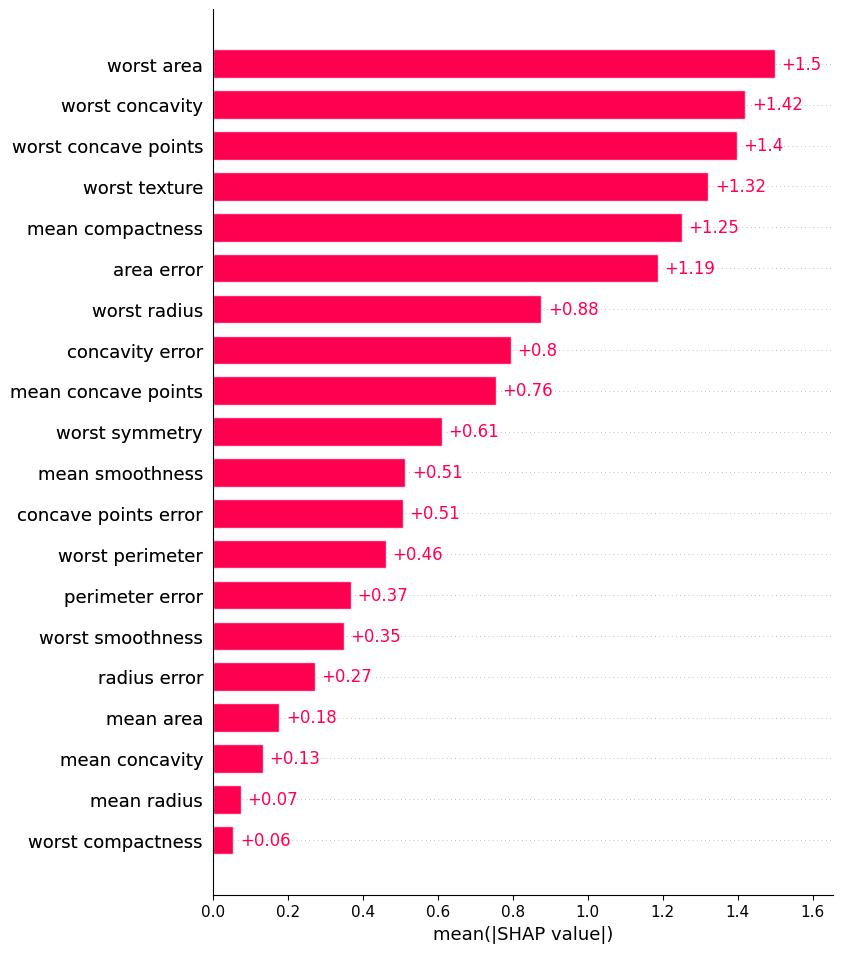

In [83]:
shap.plots.bar(shap_values,max_display=20)

The plot shows that the model primarily bases its decision on a set of variables dominated by “worst” measures (especially `worst area`, `worst concavity`, and `worst concave points`), indicating that it prioritizes extreme tumor values rather than average behavior; moreover, the strong presence of concavity-related variables reveals that boundary irregularity is the main discriminative criterion, while mean or redundant features (such as `mean radius` or `worst compactness`) contribute very little additional information. The importance of error-related variables also stands out, suggesting that the model captures some degree of heterogeneity or instability in the measurements, and overall this reflects a model that separates classes mainly based on size, extreme irregularity, and variability.

### Feature Impact Distribution (Shap Beeswarm Plot)

The beeswarm plot shows how each feature contributes to individual predictions.

- Each point represents a sample  
- The x-axis represents the SHAP value (feature contribution)  
- Color indicates the feature value (low to high)  

Interpretation of the x-axis:

- Values to the right (positive SHAP values) push the prediction toward the positive class  
- Values to the left (negative SHAP values) push the prediction toward the negative class  

Note: In this dataset, class 0 corresponds to malignant cases and class 1 to benign cases, so the direction of impact must be interpreted accordingly.



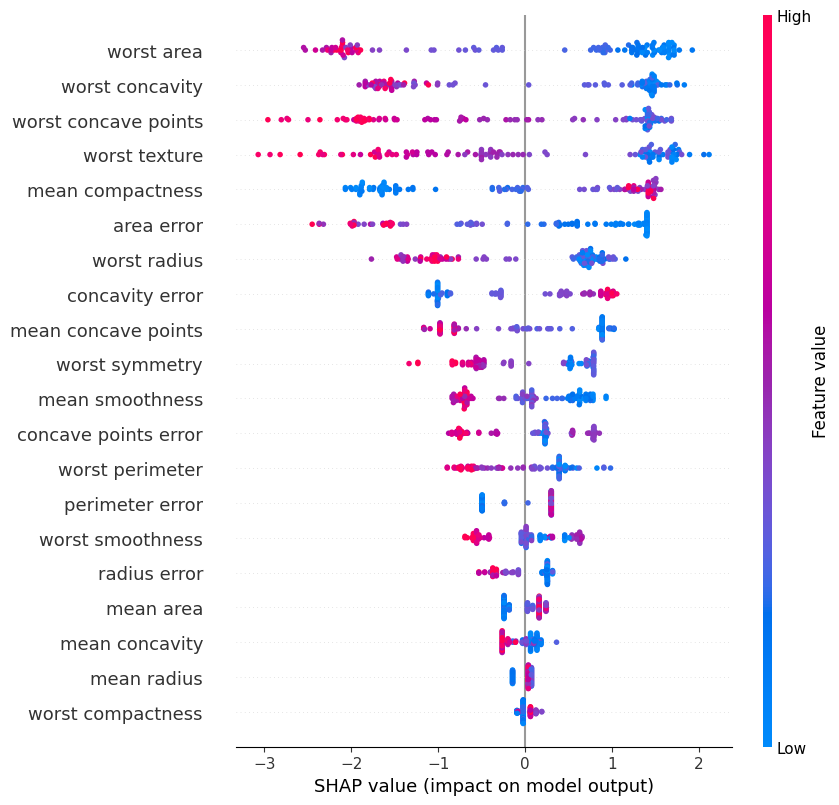

In [84]:
shap.plots.beeswarm(shap_values, max_display=20)

The beeswarm plot shows that the most influential variables (`worst area`, `worst concavity`, and `worst concave points`) exhibit a highly consistent and directional behavior: high values (red points) are mainly concentrated on the left side (negative SHAP values), pushing predictions toward class 0 (malignant), while low values (blue points) appear on the right, favoring class 1 (benign), indicating a clear and almost monotonic relationship where larger and more irregular tumors are strongly associated with malignancy; additionally, variables such as `area error` and `concavity error` display a similar pattern, suggesting that not only magnitude but also variability contributes to identifying malignant cases. Interestingly, `mean compactness` shows an inverse behavior, where higher values tend to push predictions toward the benign class, indicating that more compact structures are associated with non-malignant cases. In contrast, lower-importance features show greater color overlap on both sides of the axis. The model makes confident decisions when these key variables exhibit extreme and coherent values, but in regions where contributions approach zero and colors are mixed (especially in mean or low-impact features), ambiguous zones emerge that explain borderline cases and potential errors.


### Decision Analysis (Shap Decision Plot)

Shows how a model arrives at a prediction for one or more observations by accumulating each feature's contribution — one at a time — from a baseline value to the final output.

- **X-axis**: Model output value. With `link='logit'`, this is a probability between 0 and 1. Values above 0.5 indicate the positive class; below 0.5, the negative class.
- **Y-axis**: Features ordered from least to most impactful (bottom to top).
- **Vertical gray line**: The `expected_value` — the model's baseline prediction before any feature is considered.
- **Color bar (top)**: Encodes the final predicted class — blue for the negative class, pink/magenta for the positive class.
- **Each line**: One observation. It starts at the expected value and shifts right or left as each feature's SHAP value is added. A rightward move pushes toward the positive class; leftward toward the negative class. The line's endpoint is the final prediction.

Overlapping lines indicate similar behavior across observations. Wide divergence at a feature signals it has strong and heterogeneous effects across cases, while convergence toward the expected value suggests little discriminative power for those observations.

#### Misclassified Samples Analysis

This plot focuses only on samples that were incorrectly classified by the model.

The goal is to identify patterns or feature behaviors associated with model errors.

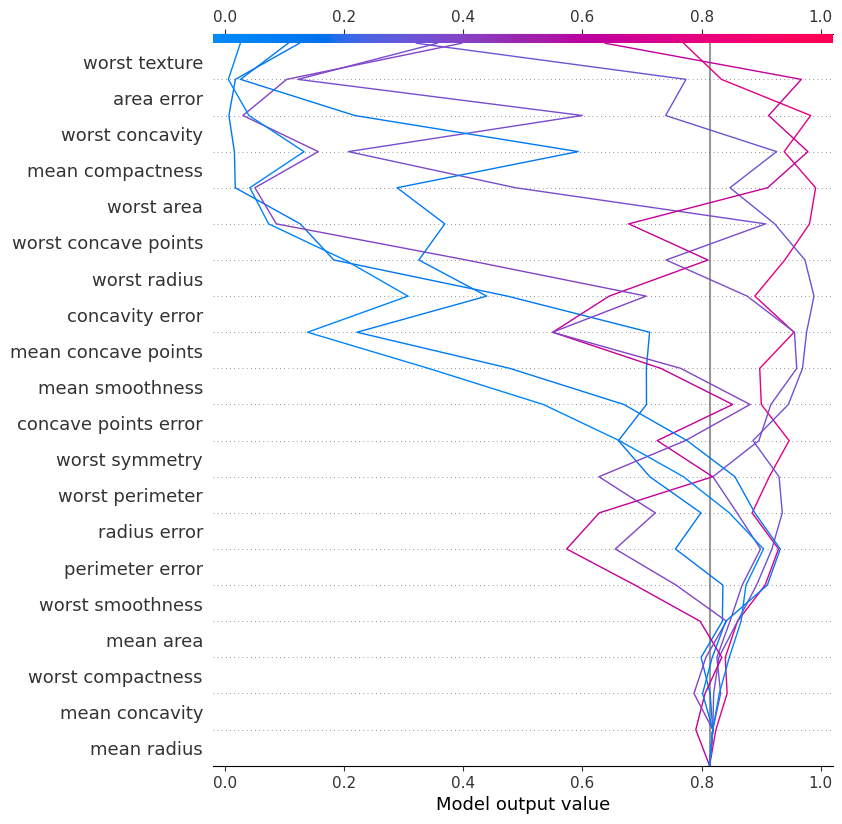

In [91]:
shap.decision_plot(
    explainer.expected_value,
    shap_values.values[misclassified_idx],
    X_test_scaled.iloc[misclassified_idx][selected_features],
    link='logit'
)

The decision plot reveals two distinct error patterns among the misclassified subjects. The model carries a strong baseline bias toward predicting benign (positive class), as evidenced by the expected value sitting near 0.8 — meaning that even before any feature is considered, the model already leans heavily toward a benign diagnosis. The pink lines, which represent subjects the model predicted as benign but who are actually malignant (false positives in terms of the benign class, or missed malignancies), begin near this high baseline and are further pushed rightward by the top features, particularly `mean compactness`,`worst texture`, `area error`, and `worst concavity`, which collectively reinforce the erroneous benign prediction instead of correcting it. The blue lines, representing subjects predicted as malignant but who are truly benign (false negatives), show a sharp leftward pull in the middle feature zone — especially around `concavity error` — which drags them below the 0.5 threshold. Overall, the misclassifications are not random: they are systematically driven by a combination of a high expected value and the influence of morphological "worst-case" measurements that, for these particular subjects, happen to point the model in the wrong direction despite the dataset having been balanced with synthetic samples.
 

#### Correctly Classified Samples Analysis

This plot shows SHAP values for correctly classified samples, highlighting clearer decision patterns.

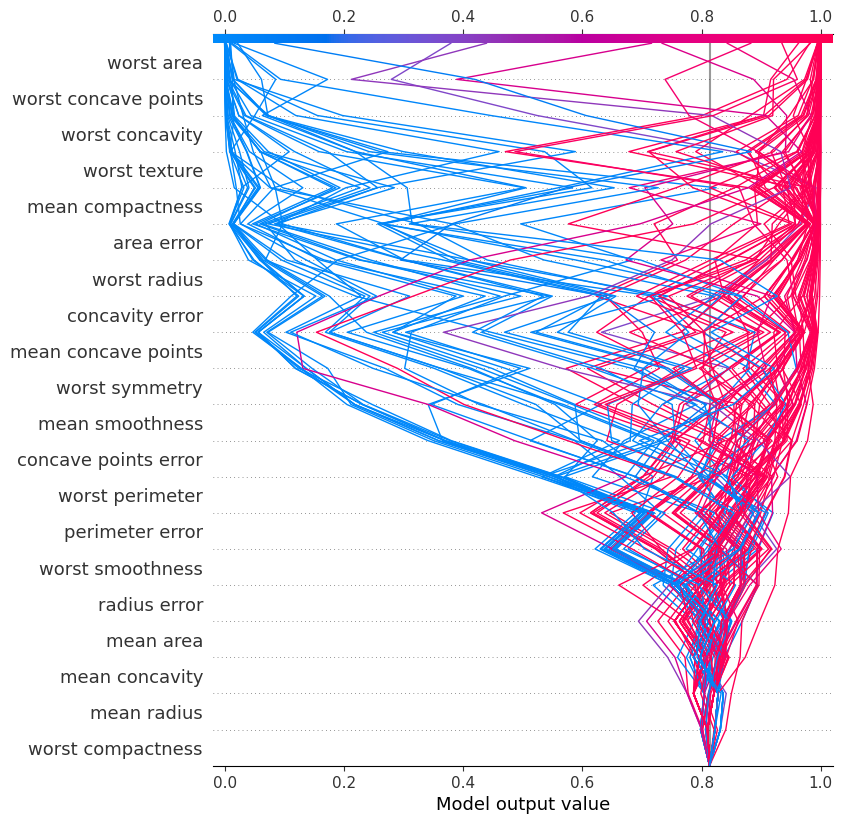

In [92]:
shap.decision_plot(
    explainer.expected_value,
    shap_values.values[correct_idx],
    X_test_scaled.iloc[correct_idx][selected_features],
    link='logit'
)

The analysis of the decision plot shows that the model starts from a high initial bias (~0.8), from which, in the lower-importance features, samples from both classes remain largely mixed without clear separation; however, as more relevant features are incorporated, separability progressively improves, with benign samples (class 1) shifting toward higher values and malignant samples (class 0) toward lower values, reflecting a gradual construction of the decision. Although a transient overlap persists in the middle region, the model manages to recover coherence and reinforce separation, indicating stability in the accumulation of evidence. Finally, the most influential features (such as `worst area`, `worst concave points`, and `worst concavity`) act mainly as confirmers of an already established trend, rather than as the sole drivers of the classification. In contrast to misclassified cases, where the decision is delayed and depends on a few final variables, correctly classified predictions are characterized by consistent, cumulative signals distributed across the entire set of features.
